In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import importlib
import pandas as pd
from datetime import datetime
from tqdm import tqdm
from plotly.subplots import make_subplots
from plotly import tools
import plotly.offline as pyo
import plotly.express as px
import plotly.io as pio
import plotly.graph_objects as go
import glob
from scipy import stats
import uproot
from ROOT import TFile, TEfficiency, TH1D, TGraphAsymmErrors, RDataFrame, TCanvas

c++: error: argument to '-isysroot' is missing (expected 1 value)
c++: error: no input files
ERROR in cling::CIFactory::createCI(): cannot extract standard library include paths!
Invoking:
  LC_ALL=C /Applications/Xcode.app/Contents/Developer/Toolchains/XcodeDefault.xctoolchain/usr/bin/c++ -isysroot;/Applications/Xcode.app/Contents/Developer/Platforms/MacOSX.platform/Developer/SDKs/MacOSX15.1.sdk   -xc++ -E -v /dev/null 2>&1 | sed -n -e '/^.include/,${' -e '/^ \/.*++/p' -e '}'
Results was:
c++: error: argument to '-isysroot' is missing (expected 1 value)
c++: error: no input files
With exit code 0


In [2]:
file = uproot.open('/Users/danielcarber/Documents/ICARUS/sbnd_data_3.root')
print(file.keys())

['events;1', 'events/mc;1', 'events/mc/POT;1', 'events/mc/Livetime;1', 'events/mc/SelectedNu_Cuts;1', 'events/mc/SelectedCos_PhaseCuts;1', 'events/mc/Efficiency_PhaseCuts;1', 'events/onbeam;1', 'events/onbeam/POT;1', 'events/onbeam/Livetime;1', 'events/onbeam/SelectedNu_Cuts;1', 'events/onbeam/SelectedCos_PhaseCuts;1']


In [34]:
mc_df = file['events/mc/SelectedNu_Cuts;1']
df = file['events/mc/SelectedCos_PhaseCuts;1']
print(mc_df.keys())
mc_df=mc_df.arrays(library='pd')
df=df.arrays(library='pd')
mc_df = pd.concat((mc_df,df))
onbeam_df = file['events/onbeam/SelectedNu_Cuts;1']
#offbeam_df = file['events/offbeam/SelectedNu_Cuts;1']

onbeam_df = onbeam_df.arrays(library='pd')
#offbeam_df = offbeam_df.arrays(library='pd')
"flash_time > -1.3 and flash_time < 0.5"
mask = (mc_df['flash_time']> 0.2) & (mc_df['flash_time']< 2.0)
mc_df =mc_df[mask]
mask = (onbeam_df['flash_time']> -1.3) & (onbeam_df['flash_time']< 0.5)
onbeam_df = onbeam_df[mask]

print(mc_df.keys())


['baseline', 'category', 'category_topology', 'flash_time', 'interaction_mode', 'nu_E', 'nu_id', 'reco_NuMI_azi', 'reco_NuMI_polar', 'reco_Q', 'reco_W', 'reco_dalphaT', 'reco_dpT', 'reco_dphiT', 'reco_electron_NuMI_angle', 'reco_electron_axial_spread', 'reco_electron_conv_dist', 'reco_electron_dedx', 'reco_electron_dir_spread', 'reco_electron_energy', 'reco_electron_pT_mag', 'reco_electron_polar', 'reco_electron_primary_score', 'reco_electron_softmax', 'reco_electron_straightness', 'reco_opening_angle', 'reco_proton_NuMI_angle', 'reco_proton_energy', 'reco_proton_muon_softmax', 'reco_proton_pT_mag', 'reco_proton_pion_softmax', 'reco_proton_polar', 'reco_proton_primary_score', 'reco_proton_softmax', 'reco_topology', 'reco_vertex_x', 'reco_vertex_y', 'reco_vertex_z', 'reco_visible_energy', 'true_NuMI_azi', 'true_NuMI_polar', 'true_Q', 'true_W', 'true_dalphaT', 'true_dpT', 'true_dphiT', 'true_electron_NuMI_angle', 'true_electron_energy', 'true_electron_pT_mag', 'true_electron_polar', 'tru

15.3106884765625
39
1
Purity of Proton's Muon Softmax < 0,04: 69.23%
Number of Signal and Total: 27, 39


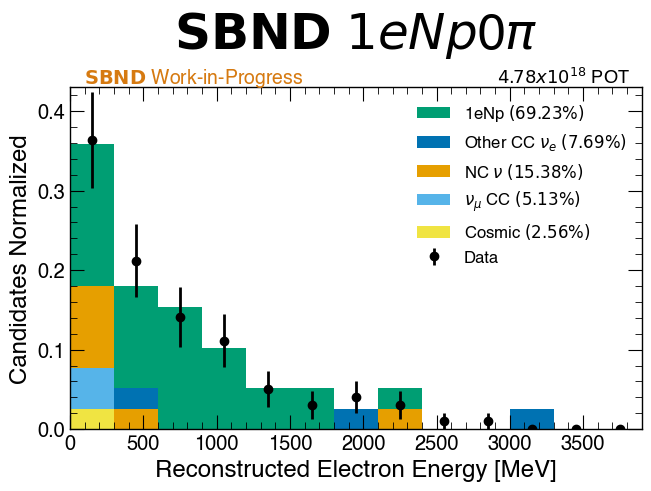

In [38]:
plt.style.use('styles/muon2024_colorswap.mplstyle')
category_assignment = [[0,1], [2,3,4,6], [5], [7],[8],[9],[11,-1], [-100]]
category_labels = ['1eNp', 'Other CC $\\nu_e$', 'NC $\\nu$', '$\\nu_\\mu$ CC','Uncontained','Other','Cosmic', 'Run 2 Data']
signal_mask  = (mc_df['category_topology']==0) | (mc_df['category_topology']==1)
other_nue_mask  = (mc_df['category_topology']==2) | (mc_df['category_topology']==3) | (mc_df['category_topology']==4)| (mc_df['category_topology']==6)
nc_mask  = (mc_df['category_topology']==5)
numu_mask  = (mc_df['category_topology']==7) 
uncontained_mask  = (mc_df['category_topology']==8)
other_mask  = (mc_df['category_topology']==9) 
cosmic_mask  = (mc_df['category_topology']==11)
signal = mc_df[signal_mask]
other_nue = mc_df[other_nue_mask]
nc = mc_df[nc_mask]
numu = mc_df[numu_mask]
uncontained = mc_df[uncontained_mask]
other = mc_df[other_mask]
cosmic = mc_df[cosmic_mask]
variable = "reco_electron_energy"
#data = [signal[variable].values,other_nue[variable].values,nc[variable].values,numu[variable].values,
#        uncontained[variable].values,other[variable].values,cosmic[variable].values]


data = [cosmic[variable].values,
        numu[variable].values,nc[variable].values,other_nue[variable].values,signal[variable].values]
print(max(mc_df[variable].values)/200)
total = sum(len(sublist) for sublist in data)
print(total)
weight = [[1/total] * len(sublist) for sublist in data]
print(len(weight[0]))
#labels =["Signal", "Other Nue", "NC", "Numu", "Uncontained", "Other", "Cosmic"]
labels =["Cosmic $(2.56\%)$", r"$\nu_\mu$ CC $(5.13\%)$",r"NC $\nu$ $(15.38\%)$", r"Other CC $\nu_e$ $(7.69\%)$", r"1eNp $(69.23\%)$"]
colors =['#009E73',  '#0072B2','#E69F00', '#56B4E9', '#F0E442']
plt.hist(data, weights=weight,bins=13,range=(0, 3900),stacked=True, label=labels,color =colors[::-1])

data = onbeam_df[variable]
counts, bins = np.histogram(data, bins=13, density = False,range=(0, 3900))

# Midpoints of bins for scatter plot
bin_centers = 0.5 * (bins[1:] + bins[:-1])

# Example scatter data (e.g., overlayed signal)
scatter_y = counts/sum(counts)  # Put points slightly above the highest bin
scatter_x = bin_centers
y_err = np.sqrt(counts)/sum(counts)
plt.errorbar(scatter_x, scatter_y,yerr=y_err, color='black',fmt='o', label='Data')


plt.xlabel("Reconstructed Electron Energy [MeV]")
plt.ylabel("Candidates Normalized")
plt.title(r"$\bf{SBND}$ $1eNp$0$\pi$")
plt.xlim(0, 3900)
plt.ylim(0, .43)
yrange = [0,.43]
usey = yrange[1] + 0.01*(yrange[1] - yrange[0]) + 0*(yrange[1] - yrange[0])
xrange = [0,3900]
usex = xrange[0] + 0.025*(xrange[1] - xrange[0]) + 0*(xrange[1] - xrange[0])
plt.text(x=usex, y=usey, s=r"$\bf{SBND}$ Work-in-Progress", fontsize=14, color='#d67a11')
usey = yrange[1] + 0.01*(yrange[1] - yrange[0]) + 0*(yrange[1] - yrange[0])
usex = xrange[1] - 0.02*(xrange[1] - xrange[0])
plt.text(x=usex, y=usey, s=r"$4.78x10^{18}$ POT", fontsize=13, color='black', horizontalalignment='right')
handles, labels = plt.gca().get_legend_handles_labels()
handles_reordered = handles[:-1][::-1] + [handles[-1]]
labels_reordered = labels[:-1][::-1] + [labels[-1]]

# Set legend
plt.legend(handles_reordered, labels_reordered)

#plt.legend()
#plt.show()
plt.savefig("/Users/danielcarber/Documents/ICARUS/NuMI_Nue/Plots/Reco_electron_energy_normalized.png")


purity = len(signal)/(len(mc_df))
print(f"Purity of Proton's Muon Softmax < 0,04: {purity*100:.2f}%")
print(f"Number of Signal and Total: {len(signal)}, {len(mc_df)}")

8.408353567138008
39
1
Purity of Proton's Muon Softmax < 0,04: 69.23%
Number of Signal and Total: 27, 39


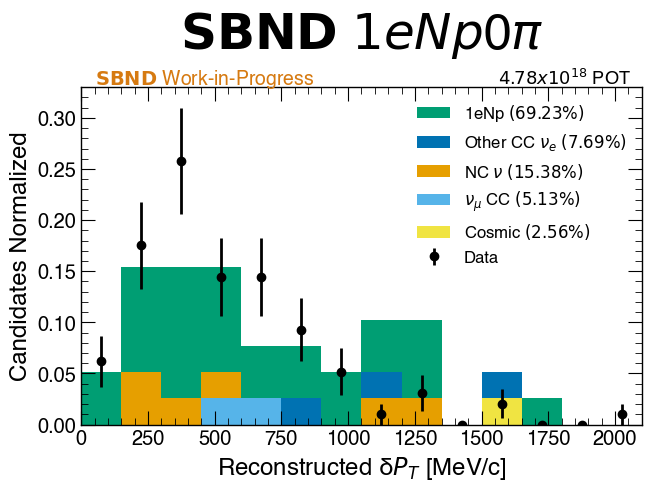

In [39]:
plt.style.use('styles/muon2024_colorswap.mplstyle')
category_assignment = [[0,1], [2,3,4,6], [5], [7],[8],[9],[11,-1], [-100]]
category_labels = ['1eNp', 'Other CC $\\nu_e$', 'NC $\\nu$', '$\\nu_\\mu$ CC','Uncontained','Other','Cosmic', 'Run 2 Data']
signal_mask  = (mc_df['category_topology']==0) | (mc_df['category_topology']==1)
other_nue_mask  = (mc_df['category_topology']==2) | (mc_df['category_topology']==3) | (mc_df['category_topology']==4)| (mc_df['category_topology']==6)
nc_mask  = (mc_df['category_topology']==5)
numu_mask  = (mc_df['category_topology']==7) 
uncontained_mask  = (mc_df['category_topology']==8)
other_mask  = (mc_df['category_topology']==9) 
cosmic_mask  = (mc_df['category_topology']==11)
signal = mc_df[signal_mask]
other_nue = mc_df[other_nue_mask]
nc = mc_df[nc_mask]
numu = mc_df[numu_mask]
uncontained = mc_df[uncontained_mask]
other = mc_df[other_mask]
cosmic = mc_df[cosmic_mask]
variable = "reco_dpT"
#data = [signal[variable].values,other_nue[variable].values,nc[variable].values,numu[variable].values,
#        uncontained[variable].values,other[variable].values,cosmic[variable].values]


data = [cosmic[variable].values,
        numu[variable].values,nc[variable].values,other_nue[variable].values,signal[variable].values]
print(max(mc_df[variable].values)/200)
total = sum(len(sublist) for sublist in data)
print(total)
weight = [[1/total] * len(sublist) for sublist in data]
print(len(weight[0]))
#labels =["Signal", "Other Nue", "NC", "Numu", "Uncontained", "Other", "Cosmic"]
labels =["Cosmic $(2.56\%)$", r"$\nu_\mu$ CC $(5.13\%)$",r"NC $\nu$ $(15.38\%)$", r"Other CC $\nu_e$ $(7.69\%)$", r"1eNp $(69.23\%)$"]
colors =['#009E73',  '#0072B2','#E69F00', '#56B4E9', '#F0E442']
plt.hist(data, weights=weight,bins=14,range=(0, 2100),stacked=True, label=labels,color =colors[::-1])

data = onbeam_df[variable]
counts, bins = np.histogram(data, bins=14, density = False,range=(0, 2100))

# Midpoints of bins for scatter plot
bin_centers = 0.5 * (bins[1:] + bins[:-1])

# Example scatter data (e.g., overlayed signal)
scatter_y = counts/sum(counts)  # Put points slightly above the highest bin
scatter_x = bin_centers
y_err = np.sqrt(counts)/sum(counts)
plt.errorbar(scatter_x, scatter_y,yerr=y_err, color='black',fmt='o', label='Data')


plt.xlabel("Reconstructed \u03B4$P_{T}$ [MeV/c]")
plt.ylabel("Candidates Normalized")
plt.title(r"$\bf{SBND}$ $1eNp$0$\pi$")
plt.xlim(0, 2100)
plt.ylim(0, .33)
yrange = [0,.33]
usey = yrange[1] + 0.01*(yrange[1] - yrange[0]) + 0*(yrange[1] - yrange[0])
xrange = [0,2100]
usex = xrange[0] + 0.025*(xrange[1] - xrange[0]) + 0*(xrange[1] - xrange[0])
plt.text(x=usex, y=usey, s=r"$\bf{SBND}$ Work-in-Progress", fontsize=14, color='#d67a11')
usey = yrange[1] + 0.01*(yrange[1] - yrange[0]) + 0*(yrange[1] - yrange[0])
usex = xrange[1] - 0.02*(xrange[1] - xrange[0])
plt.text(x=usex, y=usey, s=r"$4.78x10^{18}$ POT", fontsize=13, color='black', horizontalalignment='right')
handles, labels = plt.gca().get_legend_handles_labels()
handles_reordered = handles[:-1][::-1] + [handles[-1]]
labels_reordered = labels[:-1][::-1] + [labels[-1]]

# Set legend
plt.legend(handles_reordered, labels_reordered)

#plt.legend()
#plt.show()
plt.savefig("/Users/danielcarber/Documents/ICARUS/NuMI_Nue/Plots/Reco_electron_energy_normalized.png")


purity = len(signal)/(len(mc_df))
print(f"Purity of Proton's Muon Softmax < 0,04: {purity*100:.2f}%")
print(f"Number of Signal and Total: {len(signal)}, {len(mc_df)}")